<a href="https://colab.research.google.com/github/hrishikeshrprasad367/ML/blob/main/1BM23CS367_Lab_5_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [6]:

df_iris = pd.read_csv("iris.csv")
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
df_heart=pd.read_csv("heart.csv")
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
df_diabetes=pd.read_csv("diabetes.csv")
df_diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [10]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

In [11]:
def knn_predict(X_train, y_train, X_test, k):
    predictions = []
    for test_point in X_test:
        distances = [euclidean_distance(test_point, train_point) for train_point in X_train]
        k_indices = np.argsort(distances)[:k]
        k_labels  = [y_train[i] for i in k_indices]
        predictions.append(Counter(k_labels).most_common(1)[0][0])
    return np.array(predictions)

In [12]:
def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

def confusion_matrix_scratch(y_true, y_pred):
    classes = sorted(set(y_true))
    cm = np.zeros((len(classes), len(classes)), dtype=int)
    class_idx = {c: i for i, c in enumerate(classes)}
    for t, p in zip(y_true, y_pred):
        cm[class_idx[t]][class_idx[p]] += 1
    return cm, classes

def plot_cm_scratch(cm, classes, title):
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(title); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

[IRIS] Best K=1, Accuracy=1.0000


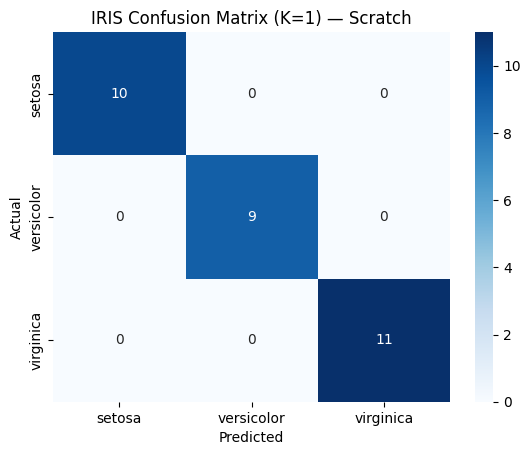

In [13]:
df_iris = pd.read_csv("iris.csv")
X_iris = df_iris.drop("species", axis=1).values
y_iris = df_iris["species"].values

X_tr, X_te, y_tr, y_te = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

# Find best K
best_k, best_acc = 1, 0
for k in range(1, 21):
    preds = knn_predict(X_tr, y_tr, X_te, k)
    acc   = accuracy(y_te, preds)
    if acc > best_acc:
        best_acc, best_k = acc, k

print(f"[IRIS] Best K={best_k}, Accuracy={best_acc:.4f}")
iris_preds = knn_predict(X_tr, y_tr, X_te, best_k)
cm, cls = confusion_matrix_scratch(y_te, iris_preds)
plot_cm_scratch(cm, cls, f"IRIS Confusion Matrix (K={best_k}) — Scratch")


[DIABETES] Best K=20, Accuracy=0.7662


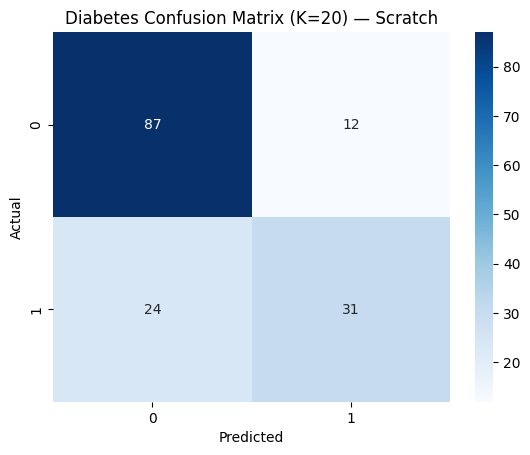

In [14]:
df_dia = pd.read_csv("diabetes.csv")
X_dia = df_dia.drop("Outcome", axis=1).values
y_dia = df_dia["Outcome"].values

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_dia, y_dia, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_tr2 = scaler.fit_transform(X_tr2)
X_te2 = scaler.transform(X_te2)

best_k2, best_acc2 = 1, 0
for k in range(1, 21):
    preds = knn_predict(X_tr2, y_tr2, X_te2, k)
    acc   = accuracy(y_te2, preds)
    if acc > best_acc2:
        best_acc2, best_k2 = acc, k

print(f"[DIABETES] Best K={best_k2}, Accuracy={best_acc2:.4f}")
dia_preds = knn_predict(X_tr2, y_tr2, X_te2, best_k2)
cm2, cls2 = confusion_matrix_scratch(y_te2, dia_preds)
plot_cm_scratch(cm2, cls2, f"Diabetes Confusion Matrix (K={best_k2}) — Scratch")

[HEART] Best K=7, Accuracy=0.9180


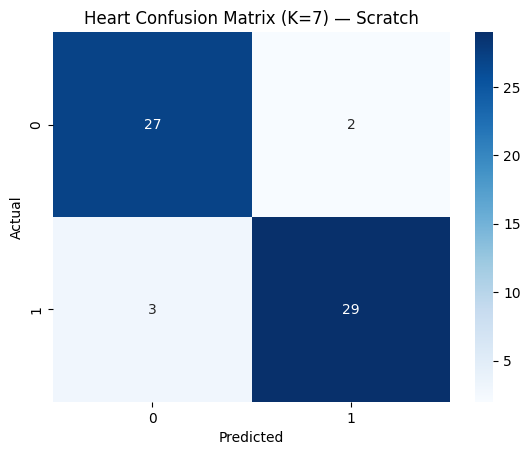

In [15]:
df_heart = pd.read_csv("heart.csv")
X_heart = df_heart.drop("target", axis=1).values
y_heart = df_heart["target"].values

X_tr3, X_te3, y_tr3, y_te3 = train_test_split(X_heart, y_heart, test_size=0.2, random_state=42)

scaler3 = StandardScaler()
X_tr3 = scaler3.fit_transform(X_tr3)
X_te3 = scaler3.transform(X_te3)

best_k3, best_acc3 = 1, 0
for k in range(1, 21):
    preds = knn_predict(X_tr3, y_tr3, X_te3, k)
    acc   = accuracy(y_te3, preds)
    if acc > best_acc3:
        best_acc3, best_k3 = acc, k

print(f"[HEART] Best K={best_k3}, Accuracy={best_acc3:.4f}")
heart_preds = knn_predict(X_tr3, y_tr3, X_te3, best_k3)
cm3, cls3 = confusion_matrix_scratch(y_te3, heart_preds)
plot_cm_scratch(cm3, cls3, f"Heart Confusion Matrix (K={best_k3}) — Scratch")


[IRIS] Best K=1, Accuracy=1.0000
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



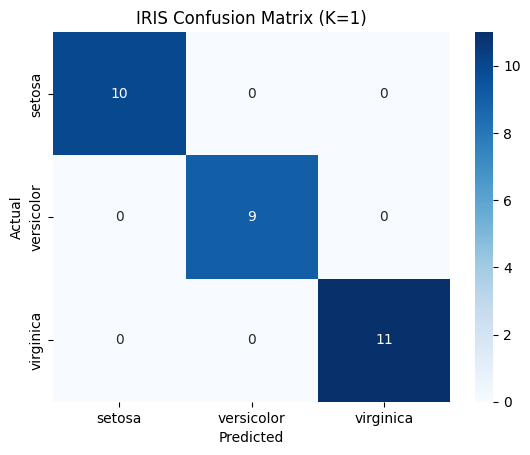

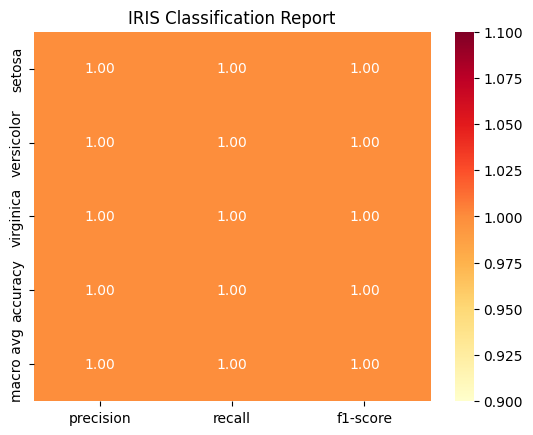


[DIABETES] Best K=18, Accuracy=0.7597
              precision    recall  f1-score   support

           0       0.77      0.89      0.83        99
           1       0.72      0.53      0.61        55

    accuracy                           0.76       154
   macro avg       0.75      0.71      0.72       154
weighted avg       0.76      0.76      0.75       154



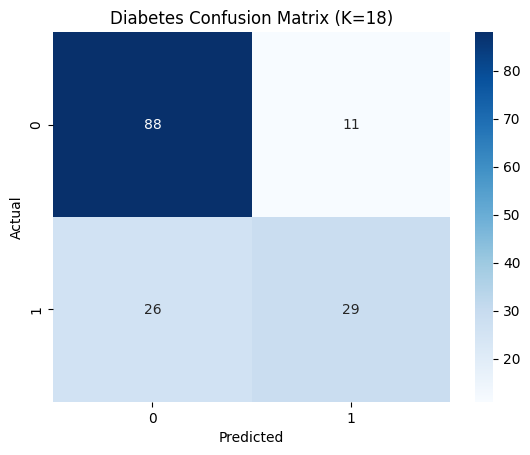

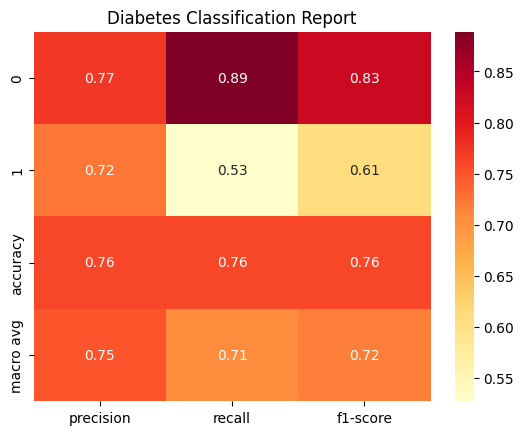


[HEART] Best K=7, Accuracy=0.9180
              precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



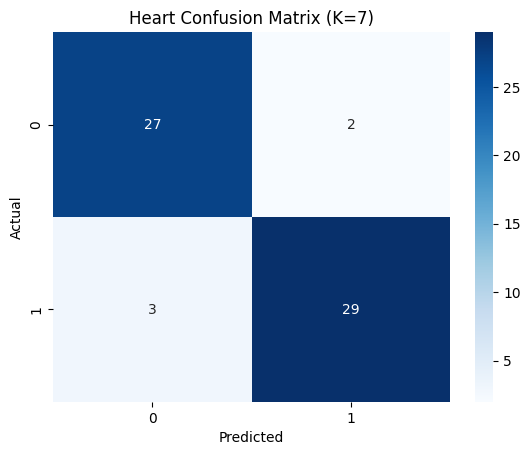

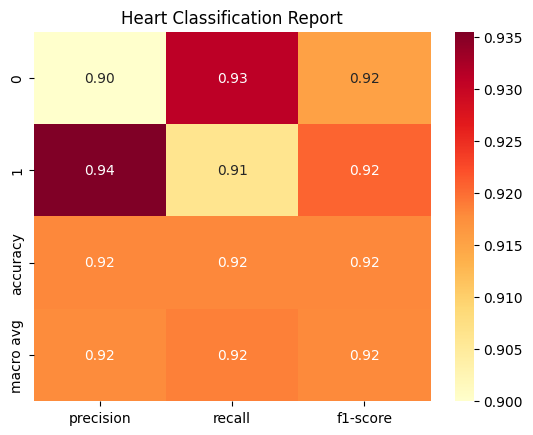

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cm(cm, title, classes=None):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(title); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

def plot_report(y_true, y_pred, title):
    report = classification_report(y_true, y_pred, output_dict=True)
    df_rep = pd.DataFrame(report).transpose()
    sns.heatmap(df_rep.iloc[:-1, :-1], annot=True, cmap='YlOrRd', fmt='.2f')
    plt.title(title); plt.show()

def best_knn(X_tr, y_tr, X_te, y_te):
    best_k, best_acc = 1, 0
    for k in range(1, 21):
        knn = KNeighborsClassifier(n_neighbors=k, algorithm='auto')
        knn.fit(X_tr, y_tr)
        acc = accuracy_score(y_te, knn.predict(X_te))
        if acc > best_acc:
            best_acc, best_k = acc, k
    return best_k

# ── IRIS ────────────────────────────────────────────────────────
df_iris = pd.read_csv("iris.csv")
X_i = df_iris.drop("species", axis=1)
y_i = df_iris["species"]
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(X_i, y_i, test_size=0.2, random_state=42)

k_iris = best_knn(Xi_tr, yi_tr, Xi_te, yi_te)
knn_iris = KNeighborsClassifier(n_neighbors=k_iris, algorithm='auto')
knn_iris.fit(Xi_tr, yi_tr)
yi_pred = knn_iris.predict(Xi_te)

print(f"\n[IRIS] Best K={k_iris}, Accuracy={accuracy_score(yi_te, yi_pred):.4f}")
print(classification_report(yi_te, yi_pred))
plot_cm(confusion_matrix(yi_te, yi_pred), f"IRIS Confusion Matrix (K={k_iris})", classes=knn_iris.classes_)
plot_report(yi_te, yi_pred, "IRIS Classification Report")

# ── DIABETES ────────────────────────────────────────────────────
df_dia = pd.read_csv("diabetes.csv")
X_d = df_dia.drop("Outcome", axis=1)
y_d = df_dia["Outcome"]
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(X_d, y_d, test_size=0.2, random_state=42)

sc = StandardScaler()
Xd_tr = sc.fit_transform(Xd_tr)
Xd_te = sc.transform(Xd_te)

k_dia = best_knn(Xd_tr, yd_tr, Xd_te, yd_te)
knn_dia = KNeighborsClassifier(n_neighbors=k_dia, algorithm='auto')
knn_dia.fit(Xd_tr, yd_tr)
yd_pred = knn_dia.predict(Xd_te)

print(f"\n[DIABETES] Best K={k_dia}, Accuracy={accuracy_score(yd_te, yd_pred):.4f}")
print(classification_report(yd_te, yd_pred))
plot_cm(confusion_matrix(yd_te, yd_pred), f"Diabetes Confusion Matrix (K={k_dia})", classes=[0, 1])  # ← fixed
plot_report(yd_te, yd_pred, "Diabetes Classification Report")

# ── HEART ───────────────────────────────────────────────────────
df_heart = pd.read_csv("heart.csv")
X_h = df_heart.drop("target", axis=1)
y_h = df_heart["target"]
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

sc2 = StandardScaler()
Xh_tr = sc2.fit_transform(Xh_tr)
Xh_te = sc2.transform(Xh_te)

k_heart = best_knn(Xh_tr, yh_tr, Xh_te, yh_te)
knn_heart = KNeighborsClassifier(n_neighbors=k_heart, algorithm='auto')
knn_heart.fit(Xh_tr, yh_tr)
yh_pred = knn_heart.predict(Xh_te)

print(f"\n[HEART] Best K={k_heart}, Accuracy={accuracy_score(yh_te, yh_pred):.4f}")
print(classification_report(yh_te, yh_pred))
plot_cm(confusion_matrix(yh_te, yh_pred), f"Heart Confusion Matrix (K={k_heart})", classes=[0, 1])  # ← fixed
plot_report(yh_te, yh_pred, "Heart Classification Report")